Импортируем необходимые библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
import scipy

Загрузим тренировочный и тестовый датасеты

In [3]:
train_df = pd.read_csv('./train.csv')

In [5]:
test_df = pd.read_csv('./test.csv')

Посмотрим на то, как выглядит таблица

In [6]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,486,0,3,"Lefebre, Miss. Jeannie",female,NaN,3,1,4133,25.4667,NaN,S
1,426,0,3,"Wiseman, Mr. Phillippe",male,NaN,0,0,A/4. 34244,7.2500,NaN,S
2,780,1,1,"Robert, Mrs. Edward Scott (Elisabeth Walton Mc...",female,43.0,0,1,24160,211.3375,B3,S
3,248,1,2,"Hamalainen, Mrs. William (Anna)",female,24.0,0,2,250649,14.5000,NaN,S
4,184,1,2,"Becker, Master. Richard F",male,1.0,2,1,230136,39.0000,F4,S


Посмотрим на график boxplot числового признака Fare по столбцу Pclass

<Axes: title={'center': 'Fare'}, xlabel='Pclass'>

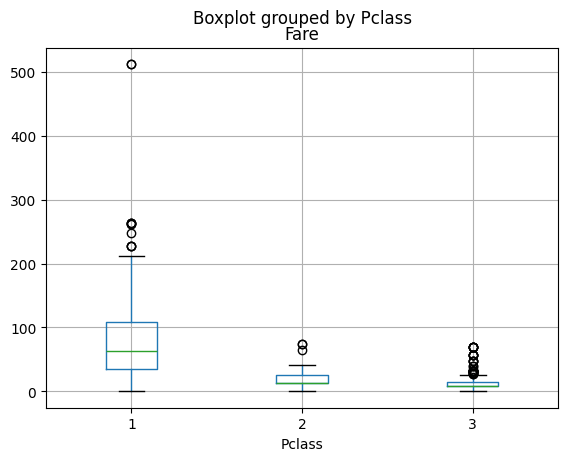

In [7]:
train_df.boxplot(column=['Fare'], by='Pclass')

Заменим выбросы на пограничные значения и создадим столбец Fare_no_out

In [12]:
train_df['Fare_no_out'] = train_df['Fare']
fare_pclass1 = train_df.loc[(train_df["Pclass"] == 1)]['Fare']
fare_pclass2 = train_df.loc[(train_df["Pclass"] == 2)]['Fare']
fare_pclass3 = train_df.loc[(train_df["Pclass"] == 3)]['Fare']

upper_1 = fare_pclass1.mean() + fare_pclass1.std() * 2
lower_1 = fare_pclass1.mean() - fare_pclass1.std() * 2

upper_2 = fare_pclass2.mean() + fare_pclass2.std() * 2
lower_2 = fare_pclass2.mean() - fare_pclass2.std() * 2

upper_3 = fare_pclass3.mean() + fare_pclass3.std() * 2
lower_3 = fare_pclass3.mean() - fare_pclass3.std() * 2
fare_pclass1_no_out = fare_pclass1.clip(lower=lower_1, upper=upper_1)
fare_pclass2_no_out = fare_pclass2.clip(lower=lower_2, upper=upper_2)
fare_pclass3_no_out = fare_pclass3.clip(lower=lower_3, upper=upper_3)
fare_no_out = pd.concat([fare_pclass1_no_out, fare_pclass2_no_out, fare_pclass3_no_out])
train_df['Fare_no_out'] = fare_no_out

Посмотрим на график boxplot после обработки выбросов

<Axes: title={'center': 'Fare_no_out'}, xlabel='Pclass'>

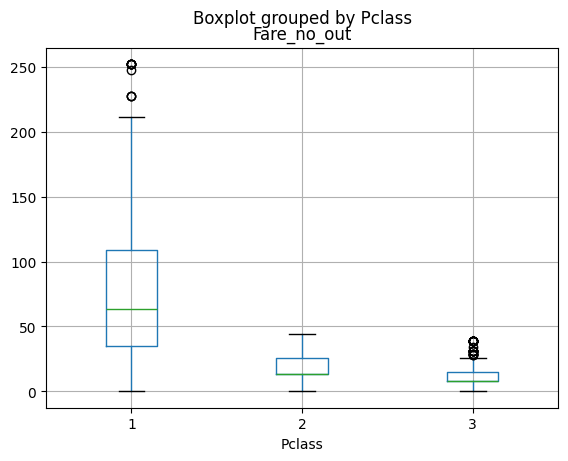

In [13]:
train_df.boxplot(column=['Fare_no_out'], by='Pclass')

In [14]:
train_df['Fare'] = train_df['Fare_no_out']

In [15]:
del train_df['Fare_no_out']

В дальнейшем будем игнорировать такие признаки, как PassengerId, Name, Ticket, так как эти признаки являются уникальными идентификаторами пассажира, на их основе невозможно выделить какие-то группы, соответственно эти признаки неинформативны


In [16]:
del train_df['PassengerId']
del train_df['Name']
del train_df['Ticket']

Визуализируем пропуски

<Axes: >

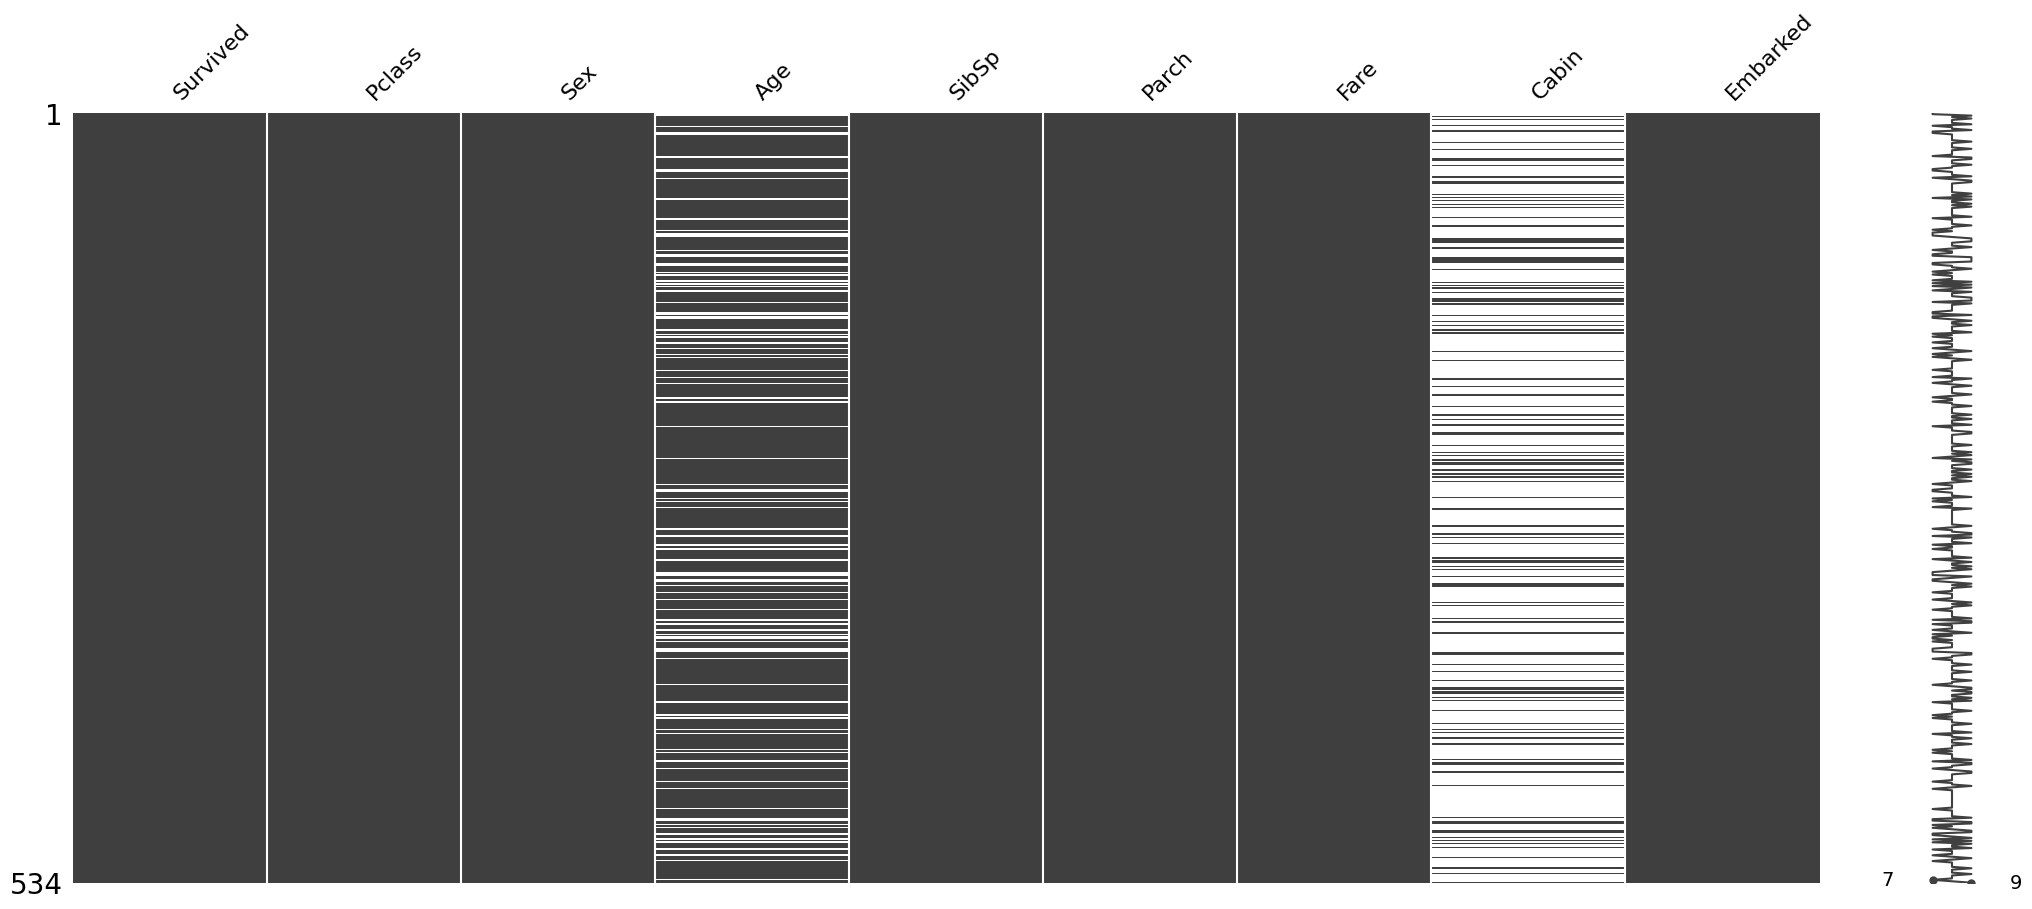

In [17]:
import missingno
missingno.matrix(train_df)

Удалим столбец Cabin, а в столбце Age заполним пропуски при помощи KNN

In [18]:
del train_df['Cabin']

In [19]:
train_df_knn = train_df.copy(deep=True)

Совершим преобразования значений ячеек, необходимые для работы алгоритма заполнения пропусков

In [20]:
train_df_knn = pd.get_dummies(train_df_knn, columns=['Sex', 'Embarked'])

Распределение значений Age до заполнения

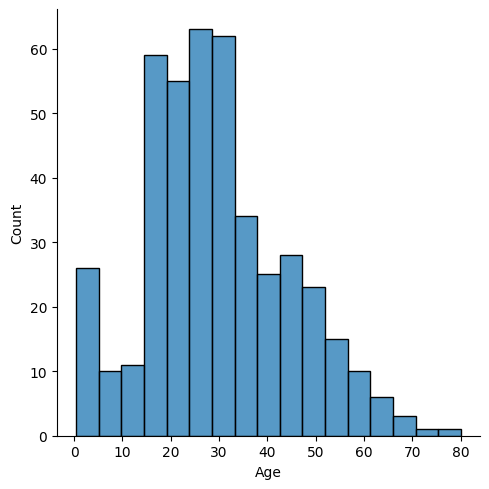

In [21]:
sns.displot(train_df['Age'], kind='hist')

Заполнение ячеек и конвертация данных из массива в DataFrame

In [22]:
from sklearn.impute import KNNImputer

In [23]:
imputer = KNNImputer()
train_df_knn = imputer.fit_transform(train_df_knn)

In [24]:
train_df_knn = pd.DataFrame(data=train_df_knn, columns=['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S'])

In [25]:
train_df['Age'] = train_df_knn['Age']

Распределение значений Age после заполнения

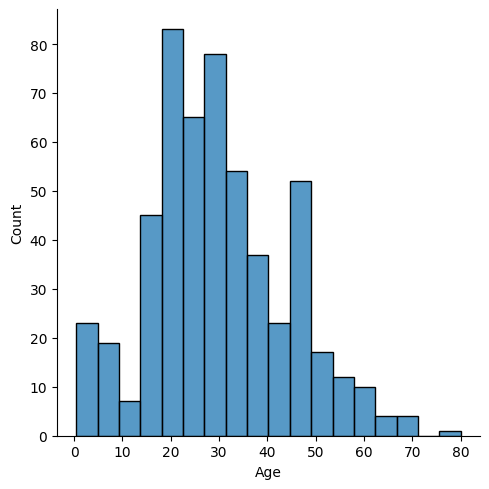

In [26]:
sns.displot(train_df['Age'], kind='hist')

Теперь закодируем значения тренировочного датасета для обучения моделей аналогичным образом, как для заполнения пропусков. Выбран OneHotEncoding, так как для представленных категориальных столбцов порядок не имеет значения.

In [27]:
train_df = pd.get_dummies(train_df, columns=['Sex', 'Embarked'])

Разобьем тренировочный Dataframe на обучающую и тестовую подвыборки

In [28]:
X = train_df.drop(columns=['Survived'])
y = train_df['Survived']

In [29]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y)

Импортируем все необходимые модели

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.svm import SVC

In [31]:
from sklearn.model_selection import GridSearchCV

Создадим сетки параметров для их подбора для каждой модели

In [32]:
param_grid_log_reg = {
    'solver' : ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
}
param_grid_knn = {
    'weights': ['uniform', 'distance'],
    'n_neighbors': [1, 3, 4, 5, 6, 7, 8, 9, 10]
}
param_grid_gaussian_nb = {
    'var_smoothing': [1e-9, 1e-7, 1e-11]
}
param_grid_lda = {
    # 'solver': ['svd', 'lsqr', 'eigen']
    'solver': ['svd', 'lsqr']
}
param_grid_qda = {
    # 'tol': [1e-4, 1e-3, 1e-5]
    'tol': [1e-4]
}
param_grid_svc = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    # 'gamma': ['scale', 'auto']
}

In [33]:
log_reg = LogisticRegression()
knn = KNeighborsRegressor()
gaussian_nb = GaussianNB()
lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()
svc = SVC()

In [34]:
param_grids = {
    log_reg: param_grid_log_reg,
    knn: param_grid_knn,
    gaussian_nb: param_grid_gaussian_nb,
    lda: param_grid_lda,
    qda: param_grid_qda,
    svc: param_grid_svc
}
models = [log_reg, knn, gaussian_nb, lda, qda, svc]

In [35]:
for model in models:
  grid_search = GridSearchCV(model, param_grids[model], scoring='roc_auc', cv=5)
  grid_search = grid_search.fit(X_train, y_train)
  print(f'Лучшие параметры для {model}: {grid_search.best_params_}')
  print(f'Лучшее значение score (ROC-AUC) для {model}: {grid_search.best_score_}')

C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Лучшие параметры для LogisticRegression(): {'solver': 'lbfgs'}
Лучшее значение score (ROC-AUC) для LogisticRegression(): 0.8276351547070441


C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 253, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 344, in _score
    response_method = _check_

Лучшие параметры для KNeighborsRegressor(): {'n_neighbors': 1, 'weights': 'uniform'}
Лучшее значение score (ROC-AUC) для KNeighborsRegressor(): nan
Лучшие параметры для GaussianNB(): {'var_smoothing': 1e-09}
Лучшее значение score (ROC-AUC) для GaussianNB(): 0.8116618389291199
Лучшие параметры для LinearDiscriminantAnalysis(): {'solver': 'svd'}
Лучшее значение score (ROC-AUC) для LinearDiscriminantAnalysis(): 0.8312318191792848


C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
C:\Users\ivans\AppData\Local\Programs\Python\

Лучшие параметры для QuadraticDiscriminantAnalysis(): {'tol': 0.0001}
Лучшее значение score (ROC-AUC) для QuadraticDiscriminantAnalysis(): 0.7442785604564406
Лучшие параметры для SVC(): {'kernel': 'linear'}
Лучшее значение score (ROC-AUC) для SVC(): 0.7878335308316876


Лучшие параметры для LogisticRegression(): {'solver': 'lbfgs'}
Лучшее значение score (ROC-AUC) для LogisticRegression(): 0.8276351547070441

Лучшие параметры для KNeighborsRegressor(): {'n_neighbors': 1, 'weights': 'uniform'}
Лучшее значение score (ROC-AUC) для KNeighborsRegressor(): nan

Лучшие параметры для GaussianNB(): {'var_smoothing': 1e-09}
Лучшее значение score (ROC-AUC) для GaussianNB(): 0.8116618389291199

Лучшие параметры для LinearDiscriminantAnalysis(): {'solver': 'svd'}
Лучшее значение score (ROC-AUC) для LinearDiscriminantAnalysis(): 0.8312318191792848

Лучшие параметры для QuadraticDiscriminantAnalysis(): {'tol': 0.0001}
Лучшее значение score (ROC-AUC) для QuadraticDiscriminantAnalysis(): 0.7442785604564406

Лучшие параметры для SVC(): {'kernel': 'linear'}
Лучшее значение score (ROC-AUC) для SVC(): 0.7878335308316876

В дальнейшем используем эти параметры для обучения моделей. Далее осуществим нормализацию признаков датасета

In [36]:
cols_to_normalize = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

In [37]:
X_train_norm = X_train.copy(deep=True)
X_test_norm = X_test.copy(deep=True)
X_train_norm[cols_to_normalize] = X_train_norm[cols_to_normalize].apply(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
X_test_norm[cols_to_normalize] = X_test_norm[cols_to_normalize].apply(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

In [38]:
log_reg = LogisticRegression(solver='liblinear')
knn = KNeighborsRegressor(weights='distance')
gaussian_nb = GaussianNB(var_smoothing=1e-09)
lda = LinearDiscriminantAnalysis(solver='svd')
qda = QuadraticDiscriminantAnalysis(tol=0.0001)
svc = SVC(kernel='linear')
models = [log_reg, knn, gaussian_nb, lda, qda, svc]

In [39]:
from sklearn.metrics import roc_auc_score

Выведем значения метрик без нормализации

In [40]:
for model in models:
  estimator = model.fit(X_train, y_train)
  y_pred = estimator.predict(X_test)
  print(f'Значение score (ROC-AUC) для {model} на тестовой выборке: {roc_auc_score(y_test, y_pred)}')

Значение score (ROC-AUC) для LogisticRegression(solver='liblinear') на тестовой выборке: 0.7461433756805806
Значение score (ROC-AUC) для KNeighborsRegressor(weights='distance') на тестовой выборке: 0.7396778584392015
Значение score (ROC-AUC) для GaussianNB() на тестовой выборке: 0.7370689655172414
Значение score (ROC-AUC) для LinearDiscriminantAnalysis() на тестовой выборке: 0.7481851179673321
Значение score (ROC-AUC) для QuadraticDiscriminantAnalysis() на тестовой выборке: 0.5192831215970962


C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


Значение score (ROC-AUC) для SVC(kernel='linear') на тестовой выборке: 0.7223230490018149


Выведем значения метрик с нормализацией

In [41]:
for model in models:
  estimator = model.fit(X_train_norm, y_train)
  y_pred = estimator.predict(X_test_norm)
  print(f'Значение score (ROC-AUC) для {model} на тестовой выборке: {roc_auc_score(y_test, y_pred)}')

Значение score (ROC-AUC) для LogisticRegression(solver='liblinear') на тестовой выборке: 0.7395644283121597
Значение score (ROC-AUC) для KNeighborsRegressor(weights='distance') на тестовой выборке: 0.7388838475499092
Значение score (ROC-AUC) для GaussianNB() на тестовой выборке: 0.7370689655172414
Значение score (ROC-AUC) для LinearDiscriminantAnalysis() на тестовой выборке: 0.7441016333938294
Значение score (ROC-AUC) для QuadraticDiscriminantAnalysis() на тестовой выборке: 0.5095281306715064
Значение score (ROC-AUC) для SVC(kernel='linear') на тестовой выборке: 0.7243647912885662


C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


Значения score для всех моделей, кроме SVC и GaussianNB, стали хуже после нормализации (у GaussianNB метрика осталась такой же)

Видим предупреждение о том, что переменные коллинеарны. Можем предположить, что речь идет об обратной зависимости Pclass и Fare, так как чем больше значение Fare, тем меньше значение Pclass

Сравним предыдущие предсказания модели с новыми, без Pclass

In [42]:
X_train_no_pclass = X_train.copy(deep=True)
X_test_no_pclass = X_test.copy(deep=True)
del X_train_no_pclass['Pclass']
del X_test_no_pclass['Pclass']

Также попробуем применить нормализацию к датасету без Pclass

In [43]:
X_train_no_pclass_norm = X_train_no_pclass.copy(deep=True)
X_test_no_pclass_norm = X_test_no_pclass.copy(deep=True)
cols_to_normalize = ['Age', 'SibSp', 'Parch', 'Fare']
X_train_no_pclass_norm[cols_to_normalize] = X_train_no_pclass_norm[cols_to_normalize].apply(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
X_test_no_pclass_norm[cols_to_normalize] = X_test_no_pclass_norm[cols_to_normalize].apply(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

Без нормализации и без Pclass

In [44]:
for model in models:
  estimator = model.fit(X_train_no_pclass, y_train)
  y_pred = estimator.predict(X_test_no_pclass)
  print(f'Значение score (ROC-AUC) для {model} на тестовой выборке: {roc_auc_score(y_test, y_pred)}')

Значение score (ROC-AUC) для LogisticRegression(solver='liblinear') на тестовой выборке: 0.7289019963702359
Значение score (ROC-AUC) для KNeighborsRegressor(weights='distance') на тестовой выборке: 0.742513611615245
Значение score (ROC-AUC) для GaussianNB() на тестовой выборке: 0.7568058076225045
Значение score (ROC-AUC) для LinearDiscriminantAnalysis() на тестовой выборке: 0.7375226860254084
Значение score (ROC-AUC) для QuadraticDiscriminantAnalysis() на тестовой выборке: 0.5499092558983666


C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


Значение score (ROC-AUC) для SVC(kernel='linear') на тестовой выборке: 0.7223230490018149


С нормализацией и без Pclass

In [45]:
for model in models:
  estimator = model.fit(X_train_no_pclass_norm, y_train)
  y_pred = estimator.predict(X_test_no_pclass_norm)
  print(f'Значение score (ROC-AUC) для {model} на тестовой выборке: {roc_auc_score(y_test, y_pred)}')

Значение score (ROC-AUC) для LogisticRegression(solver='liblinear') на тестовой выборке: 0.7309437386569874
Значение score (ROC-AUC) для KNeighborsRegressor(weights='distance') на тестовой выборке: 0.7752949183303086
Значение score (ROC-AUC) для GaussianNB() на тестовой выборке: 0.741606170598911
Значение score (ROC-AUC) для LinearDiscriminantAnalysis() на тестовой выборке: 0.7375226860254084
Значение score (ROC-AUC) для QuadraticDiscriminantAnalysis() на тестовой выборке: 0.6982758620689655
Значение score (ROC-AUC) для SVC(kernel='linear') на тестовой выборке: 0.7243647912885662


C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


Лучший результат на тестовой выборке показывает модель KNN без нормализации и признака Pclass

Попробуем осуществить подбор наиболее информативных признаков при помощи sklearn.feature_selection.SelectKBest

In [46]:
from sklearn.feature_selection import SelectKBest, chi2, f_regression, f_classif

In [47]:
selector = SelectKBest(chi2, k='all')
selector.fit(X, y)
X_selected = selector.transform(X)
scores = selector.scores_
for i in range(len(X.columns)):
  print(f'{X.columns[i]}: {scores[i]}')

Pclass: 19.24817069368367
Age: 29.56071902555113
SibSp: 2.3022461784667634
Parch: 5.663488525993065
Fare: 3053.701800055579
Sex_female: 89.81322923437146
Sex_male: 48.80025172272205
Embarked_C: 20.978767272584335
Embarked_Q: 0.07596873714520785
Embarked_S: 5.214977974933655


In [48]:
selector = SelectKBest(f_regression, k='all')
selector.fit(X, y)
X_selected = selector.transform(X)
scores = selector.scores_
for i in range(len(X.columns)):
  print(f'{X.columns[i]}: {scores[i]}')

Pclass: 72.0453021962164
Age: 4.454661715609973
SibSp: 0.8671702715059882
Parch: 3.220291067136406
Fare: 52.77036576563196
Sex_female: 186.50704644072965
Sex_male: 186.5070464407302
Embarked_C: 27.219820092669597
Embarked_Q: 0.08368887349748048
Embarked_S: 18.64682509639517


In [49]:
selector = SelectKBest(f_classif, k='all')
selector.fit(X, y)
X_selected = selector.transform(X)
scores = selector.scores_
for i in range(len(X.columns)):
  print(f'{X.columns[i]}: {scores[i]}')

Pclass: 72.04530219621638
Age: 4.454661715610333
SibSp: 0.8671702715059718
Parch: 3.2202910671364022
Fare: 52.770365765632064
Sex_female: 186.5070464407294
Sex_male: 186.50704644072948
Embarked_C: 27.219820092669604
Embarked_Q: 0.0836888734974808
Embarked_S: 18.64682509639506


In [50]:
from sklearn.feature_selection import RFE

In [51]:
from sklearn.feature_selection import SelectFromModel

In [52]:
models_rfe = [log_reg, lda, svc]

In [53]:
for model in models_rfe:
  try:
    rfe = RFE(model, n_features_to_select=5, step=1)
    rfe = rfe.fit(X, y)
    scores = rfe.ranking_
    print(model)
    for i in range(len(X.columns)):
      print(f'{X.columns[i]}: {scores[i]}')
    print('\n\n')
  except Exception as e:
    print(e)

LogisticRegression(solver='liblinear')
Pclass: 1
Age: 5
SibSp: 2
Parch: 3
Fare: 6
Sex_female: 1
Sex_male: 1
Embarked_C: 1
Embarked_Q: 1
Embarked_S: 4



LinearDiscriminantAnalysis()
Pclass: 1
Age: 5
SibSp: 2
Parch: 3
Fare: 6
Sex_female: 1
Sex_male: 1
Embarked_C: 1
Embarked_Q: 4
Embarked_S: 1



SVC(kernel='linear')
Pclass: 1
Age: 5
SibSp: 1
Parch: 2
Fare: 6
Sex_female: 1
Sex_male: 1
Embarked_C: 3
Embarked_Q: 4
Embarked_S: 1





Различные методы показывают, что наименее результативны признаки Age, Fare, SibSp, Parch. Попробуем исключить некоторые из них или все

In [54]:
X_train_drop_1 = X_train.copy(deep=True)
X_test_drop_1 = X_test.copy(deep=True)
del X_train_drop_1['Age']
del X_train_drop_1['Fare']
del X_test_drop_1['Age']
del X_test_drop_1['Fare']

In [55]:
for model in models:
  estimator = model.fit(X_train_drop_1, y_train)
  y_pred = estimator.predict(X_test_drop_1)
  print(f'Значение score (ROC-AUC) для {model} на тестовой выборке: {roc_auc_score(y_test, y_pred)}')

Значение score (ROC-AUC) для LogisticRegression(solver='liblinear') на тестовой выборке: 0.7177858439201452
Значение score (ROC-AUC) для KNeighborsRegressor(weights='distance') на тестовой выборке: 0.6947595281306715
Значение score (ROC-AUC) для GaussianNB() на тестовой выборке: 0.728448275862069
Значение score (ROC-AUC) для LinearDiscriminantAnalysis() на тестовой выборке: 0.7289019963702359
Значение score (ROC-AUC) для QuadraticDiscriminantAnalysis() на тестовой выборке: 0.5136116152450091
Значение score (ROC-AUC) для SVC(kernel='linear') на тестовой выборке: 0.7243647912885662


C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


In [56]:
X_train_drop_2 = X_train.copy(deep=True)
X_test_drop_2 = X_test.copy(deep=True)
del X_train_drop_2['Age']
del X_train_drop_2['Fare']
del X_train_drop_2['SibSp']
del X_train_drop_2['Parch']
del X_test_drop_2['Age']
del X_test_drop_2['Fare']
del X_test_drop_2['SibSp']
del X_test_drop_2['Parch']

In [57]:
for model in models:
  estimator = model.fit(X_train_drop_2, y_train)
  y_pred = estimator.predict(X_test_drop_2)
  print(f'Значение score (ROC-AUC) для {model} на тестовой выборке: {roc_auc_score(y_test, y_pred)}')

Значение score (ROC-AUC) для LogisticRegression(solver='liblinear') на тестовой выборке: 0.7239110707803991
Значение score (ROC-AUC) для KNeighborsRegressor(weights='distance') на тестовой выборке: 0.7578266787658802
Значение score (ROC-AUC) для GaussianNB() на тестовой выборке: 0.7325317604355717
Значение score (ROC-AUC) для LinearDiscriminantAnalysis() на тестовой выборке: 0.7243647912885662
Значение score (ROC-AUC) для QuadraticDiscriminantAnalysis() на тестовой выборке: 0.5
Значение score (ROC-AUC) для SVC(kernel='linear') на тестовой выборке: 0.7243647912885662


C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


In [58]:
X_train_drop_3 = X_train.copy(deep=True)
X_test_drop_3 = X_test.copy(deep=True)
del X_train_drop_3['Embarked_C']
del X_train_drop_3['Embarked_Q']
del X_train_drop_3['Embarked_S']

del X_test_drop_3['Embarked_C']
del X_test_drop_3['Embarked_Q']
del X_test_drop_3['Embarked_S']


In [59]:
for model in models:
  estimator = model.fit(X_train_drop_3, y_train)
  y_pred = estimator.predict(X_test_drop_3)
  print(f'Значение score (ROC-AUC) для {model} на тестовой выборке: {roc_auc_score(y_test, y_pred)}')

Значение score (ROC-AUC) для LogisticRegression(solver='liblinear') на тестовой выборке: 0.7481851179673321
Значение score (ROC-AUC) для KNeighborsRegressor(weights='distance') на тестовой выборке: 0.7472776769509982
Значение score (ROC-AUC) для GaussianNB() на тестовой выборке: 0.7198275862068966
Значение score (ROC-AUC) для LinearDiscriminantAnalysis() на тестовой выборке: 0.7568058076225045
Значение score (ROC-AUC) для QuadraticDiscriminantAnalysis() на тестовой выборке: 0.6755898366606171


C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


Значение score (ROC-AUC) для SVC(kernel='linear') на тестовой выборке: 0.7223230490018149


In [60]:
X_train_drop_4 = X_train.copy(deep=True)
X_test_drop_4 = X_test.copy(deep=True)

del X_train_drop_4['Fare']

del X_test_drop_4['Fare']

In [61]:
for model in models:
  estimator = model.fit(X_train_drop_4, y_train)
  y_pred = estimator.predict(X_test_drop_4)
  print(f'Значение score (ROC-AUC) для {model} на тестовой выборке: {roc_auc_score(y_test, y_pred)}')

Значение score (ROC-AUC) для LogisticRegression(solver='liblinear') на тестовой выборке: 0.7243647912885662
Значение score (ROC-AUC) для KNeighborsRegressor(weights='distance') на тестовой выборке: 0.7923094373865698
Значение score (ROC-AUC) для GaussianNB() на тестовой выборке: 0.728448275862069
Значение score (ROC-AUC) для LinearDiscriminantAnalysis() на тестовой выборке: 0.7264065335753176
Значение score (ROC-AUC) для QuadraticDiscriminantAnalysis() на тестовой выборке: 0.5086206896551724
Значение score (ROC-AUC) для SVC(kernel='linear') на тестовой выборке: 0.7243647912885662


C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


In [62]:
X_train_drop_5 = X_train.copy(deep=True)
X_test_drop_5 = X_test.copy(deep=True)
del X_train_drop_5['Embarked_C']
del X_train_drop_5['Embarked_Q']
del X_train_drop_5['Embarked_S']

del X_test_drop_5['Embarked_C']
del X_test_drop_5['Embarked_Q']
del X_test_drop_5['Embarked_S']

del X_train_drop_5['Fare']

del X_test_drop_5['Fare']

In [63]:
for model in models:
  estimator = model.fit(X_train_drop_5, y_train)
  y_pred = estimator.predict(X_test_drop_5)
  print(f'Значение score (ROC-AUC) для {model} на тестовой выборке: {roc_auc_score(y_test, y_pred)}')

Значение score (ROC-AUC) для LogisticRegression(solver='liblinear') на тестовой выборке: 0.7481851179673321
Значение score (ROC-AUC) для KNeighborsRegressor(weights='distance') на тестовой выборке: 0.7932168784029039
Значение score (ROC-AUC) для GaussianNB() на тестовой выборке: 0.7289019963702359
Значение score (ROC-AUC) для LinearDiscriminantAnalysis() на тестовой выборке: 0.7568058076225045
Значение score (ROC-AUC) для QuadraticDiscriminantAnalysis() на тестовой выборке: 0.45598911070780396


C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


Значение score (ROC-AUC) для SVC(kernel='linear') на тестовой выборке: 0.7243647912885662


Максимальный результат по метрике ROC-AUC показала модель KNN на датасете без признака Fare

In [64]:
del test_df['PassengerId']
del test_df['Name']
del test_df['Ticket']
del test_df['Cabin']
del test_df['Fare']

In [65]:
test_df = pd.get_dummies(test_df, columns=['Sex', 'Embarked'])

In [66]:
cols = test_df.columns

In [67]:
imputer = KNNImputer()
test_df = imputer.fit_transform(test_df)
test_df = pd.DataFrame(data=test_df, columns=cols)

In [68]:
del X['Fare']

In [69]:
X

,Pclass,Age,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,17.6,3,1,True,False,False,False,True
1,3,22.1,0,0,False,True,False,False,True
2,1,43.0,0,1,True,False,False,False,True
3,2,24.0,0,2,True,False,False,False,True
4,2,1.0,2,1,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...
529,3,2.0,3,2,True,False,False,False,True
530,3,3.0,3,1,True,False,False,False,True
531,3,34.6,3,1,False,True,False,False,True
532,2,24.0,2,3,True,False,False,False,True


In [70]:
model = KNeighborsRegressor(weights='distance')
model = model.fit(X, y)
preds = model.predict(test_df)

После получения низкого значения score на соревновательном датасете принято решение нормализовать данные

In [71]:
cols_to_normalize = ['Pclass', 'Age', 'SibSp', 'Parch']

In [72]:
X_train_norm = X.copy(deep=True)
X_test_norm = test_df.copy(deep=True)
X_train_norm[cols_to_normalize] = X_train_norm[cols_to_normalize].apply(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
X_test_norm[cols_to_normalize] = X_test_norm[cols_to_normalize].apply(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

In [73]:
model = KNeighborsRegressor(weights='distance')
model = model.fit(X_train_norm, y)
preds = model.predict(X_test_norm)

После нормализации получено значение score 0.841, принято решение попробовать добавить сэмплирование

In [76]:
from imblearn.over_sampling import RandomOverSampler 

In [77]:
ros = RandomOverSampler(random_state=0)

X_resampled, y_resampled = ros.fit_resample(X_train_norm, y)

In [78]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=0)

X_resampled_under, y_resampled_under = rus.fit_resample(X_train_norm, y)

Oversampling повысил результат до 0.842, undersampling понизил до 0.8367


In [79]:
from imblearn.combine import SMOTEENN

smote_enn = SMOTEENN(random_state=0)

X_resampled_comb, y_resampled_comb = smote_enn.fit_resample(X_train_norm, y)

Комбинация over- и undersampling под названием SMOTEENN дала результат 0.83695

In [80]:
preds = []

In [81]:
for model in models:
  model = model.fit(X_resampled, y_resampled)
  preds.append(model.predict(X_test_norm))

C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


In [82]:
model = KNeighborsRegressor(n_neighbors=9)
model = model.fit(X_resampled, y_resampled)
preds = model.predict(X_test_norm)

In [83]:
model = KNeighborsRegressor(weights='distance')
model = model.fit(X_resampled_under, y_resampled_under)
preds = model.predict(X_test_norm)

In [84]:
model = KNeighborsRegressor(weights='distance')
model = model.fit(X_resampled_comb, y_resampled_comb)
preds = model.predict(X_test_norm)

In [87]:
original_test_df = pd.read_csv('./test.csv')

In [88]:
original_test_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,384,1,"Holverson, Mrs. Alexander Oskar (Mary Aline To...",female,35.0,1,0,113789,52.0000,NaN,S
1,882,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
2,276,1,"Andrews, Miss. Kornelia Theodosia",female,63.0,1,0,13502,77.9583,D7,S
3,648,1,"Simonius-Blumer, Col. Oberst Alfons",male,56.0,0,0,13213,35.5000,A26,C
4,224,3,"Nenkoff, Mr. Christo",male,NaN,0,0,349234,7.8958,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
352,115,3,"Attalah, Miss. Malake",female,17.0,0,0,2627,14.4583,NaN,C
353,539,3,"Risien, Mr. Samuel Beard",male,NaN,0,0,364498,14.5000,NaN,S
354,656,2,"Hickman, Mr. Leonard Mark",male,24.0,2,0,S.O.C. 14879,73.5000,NaN,S
355,11,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S


In [89]:
output = pd.DataFrame({'PassengerId': original_test_df['PassengerId'], 'Survived': preds})

In [90]:
output.to_csv('./output.csv', index=False)

Лучший результат - 0.86852 для модели KNN с n_neighbors = 9, weights = 'uniform', нормализацией, использованием Oversampling и без признака Fare

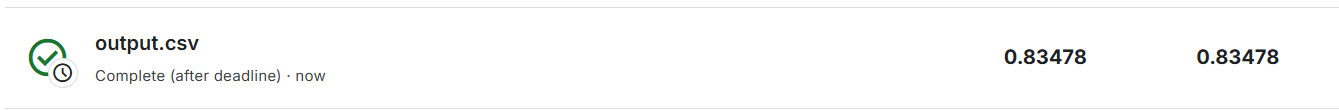